<a href="https://colab.research.google.com/github/gretadive/correlacion_actividad_solar_elnino/blob/main/notebooks/%2007_analisis_exploratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Análisis exploratorio de las variables**
Este notebook realiza el análisis exploratorio del dataset integrado compuesto por las series temporales ICEN, ONI, SSN y precipitación ERA5.

El análisis se realiza utilizando los valores originales de las variables, con el propósito de evaluar:

- estructura y calidad del dataset;
- periodo temporal disponible;
- valores faltantes y duplicados;
- estadísticos descriptivos;
- rangos y diferencias de escala;
- distribución de las variables;
- posibles valores atípicos;
- comportamiento temporal de cada serie.



In [1]:
import os
import subprocess

usuario = "gretadive"
repo = "correlacion_actividad_solar_elnino"
ruta_repo = f"/content/{repo}"

if not os.path.exists(ruta_repo):
    subprocess.run(
        [
            "git",
            "clone",
            f"https://github.com/{usuario}/{repo}.git"
        ],
        check=True
    )
    print("✅ Repositorio clonado correctamente")
else:
    print("✅ El repositorio ya está disponible")

✅ Repositorio clonado correctamente


In [2]:
%cd /content/correlacion_actividad_solar_elnino

/content/correlacion_actividad_solar_elnino


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv(
    "data/processed/dataset_integrado_precipitacion.csv",
    parse_dates=["fecha"]
)

dataset.head()

,fecha,anio,mes,ICEN,ONI,SSN,precipitacion_mm
0,1950-01-01,1950,1,-0.75,-1.32,143.9,155.309817
1,1950-02-01,1950,2,-1.07,-1.20,134.3,164.955825
2,1950-03-01,1950,3,-1.25,-1.12,155.4,158.180623
3,1950-04-01,1950,4,-1.18,-1.08,160.6,221.687990
4,1950-05-01,1950,5,-1.22,-1.10,150.5,123.802819


In [4]:
print("Dimensiones:", dataset.shape)

print("\nPeriodo:")
print(
    dataset["fecha"].min(),
    "a",
    dataset["fecha"].max()
)

print("\nColumnas:")
print(dataset.columns.tolist())

print("\nTipos de datos:")
print(dataset.dtypes)

Dimensiones: (917, 7)

Periodo:
1950-01-01 00:00:00 a 2026-05-01 00:00:00

Columnas:
['fecha', 'anio', 'mes', 'ICEN', 'ONI', 'SSN', 'precipitacion_mm']

Tipos de datos:
fecha               datetime64[ns]
anio                         int64
mes                          int64
ICEN                       float64
ONI                        float64
SSN                        float64
precipitacion_mm           float64
dtype: object


In [5]:
fechas_esperadas = pd.date_range(
    start=dataset["fecha"].min(),
    end=dataset["fecha"].max(),
    freq="MS"
)

fechas_faltantes = fechas_esperadas.difference(
    dataset["fecha"]
)

print("Meses faltantes:", len(fechas_faltantes))

if len(fechas_faltantes) == 0:
    print("✅ Serie temporal mensual continua")
else:
    print(fechas_faltantes)

Meses faltantes: 0
✅ Serie temporal mensual continua


In [6]:
variables = [
    "ICEN",
    "ONI",
    "SSN",
    "precipitacion_mm"
]

dataset[variables].describe().T

,count,mean,std,min,25%,50%,75%,max
ICEN,917.0,0.002737,1.018758,-2.230000,-0.690000,-0.200000,0.490000,4.320000
ONI,917.0,0.015213,0.784956,-2.040000,-0.510000,-0.040000,0.500000,2.590000
SSN,917.0,91.322137,73.625869,0.000000,27.400000,74.800000,140.800000,359.400000
precipitacion_mm,917.0,140.750830,78.987686,17.855862,79.560383,123.875436,180.205852,596.482079


In [7]:
#Estadísticos descriptivos
for variable in variables:
    print(f"\n{variable}")
    print("Mínimo:", dataset[variable].min())
    print("Máximo:", dataset[variable].max())
    print("Media:", dataset[variable].mean())
    print("Desviación estándar:", dataset[variable].std())


ICEN
Mínimo: -2.23
Máximo: 4.32
Media: 0.0027371864776444986
Desviación estándar: 1.0187575003940363

ONI
Mínimo: -2.04
Máximo: 2.59
Media: 0.015212649945474372
Desviación estándar: 0.7849563192122507

SSN
Mínimo: 0.0
Máximo: 359.4
Media: 91.32213740458015
Desviación estándar: 73.6258685242526

precipitacion_mm
Mínimo: 17.855861590445656
Máximo: 596.4820790792833
Media: 140.75083036515647
Desviación estándar: 78.98768624109412


In [8]:
#Comparar rangos

resumen_escalas = pd.DataFrame({
    "Variable": variables,
    "Mínimo": [dataset[v].min() for v in variables],
    "Máximo": [dataset[v].max() for v in variables],
    "Media": [dataset[v].mean() for v in variables],
    "Desviación estándar": [dataset[v].std() for v in variables]
})

resumen_escalas

,Variable,Mínimo,Máximo,Media,Desviación estándar
0,ICEN,-2.230000,4.320000,0.002737,1.018758
1,ONI,-2.040000,2.590000,0.015213,0.784956
2,SSN,0.000000,359.400000,91.322137,73.625869
3,precipitacion_mm,17.855862,596.482079,140.750830,78.987686


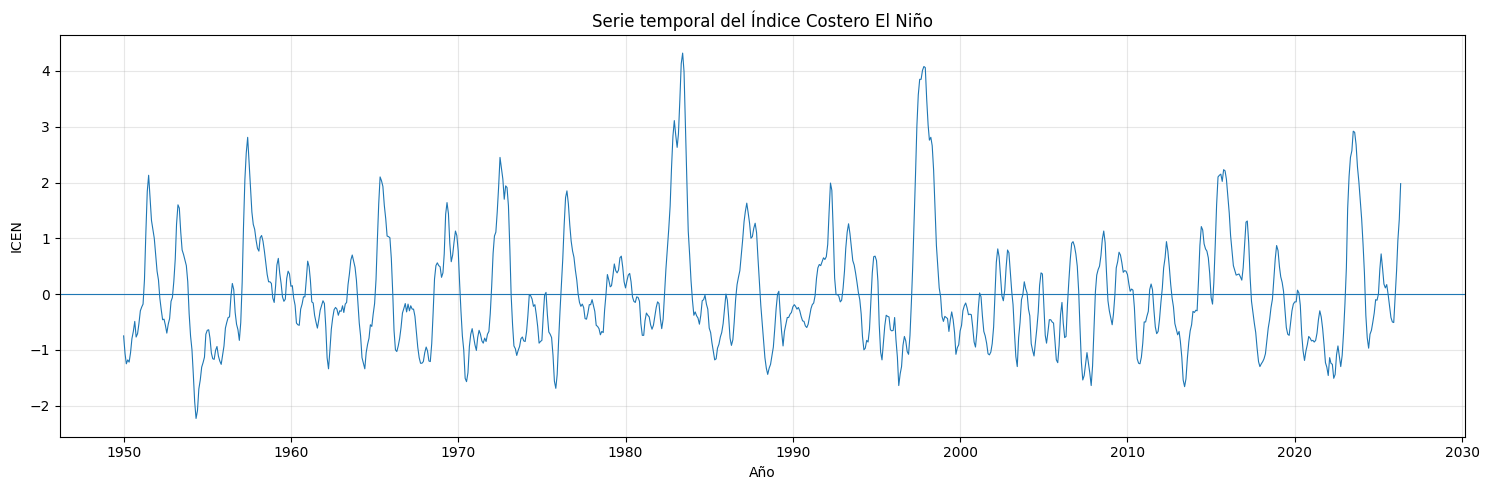

In [9]:
#Serie temporal ICEN

plt.figure(figsize=(15,5))

plt.plot(
    dataset["fecha"],
    dataset["ICEN"],
    linewidth=0.8
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Año")
plt.ylabel("ICEN")
plt.title("Serie temporal del Índice Costero El Niño")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

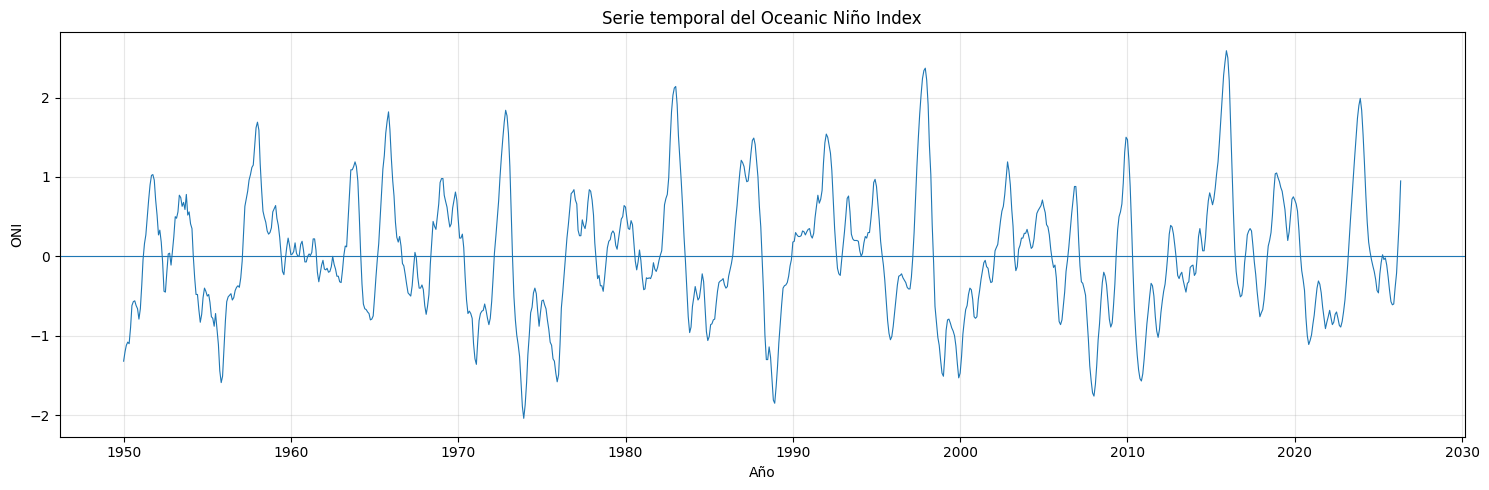

In [10]:
#Serie temporal ONI

plt.figure(figsize=(15,5))

plt.plot(
    dataset["fecha"],
    dataset["ONI"],
    linewidth=0.8
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Año")
plt.ylabel("ONI")
plt.title("Serie temporal del Oceanic Niño Index")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

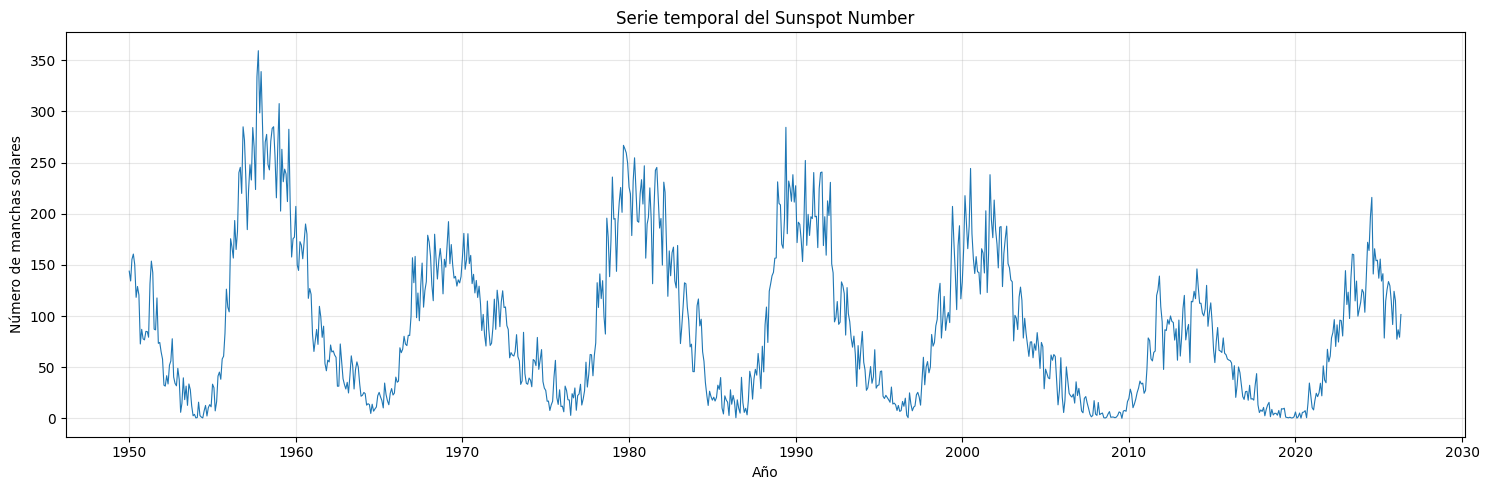

In [11]:
#Serie temporal SSN

plt.figure(figsize=(15,5))

plt.plot(
    dataset["fecha"],
    dataset["SSN"],
    linewidth=0.8
)

plt.xlabel("Año")
plt.ylabel("Número de manchas solares")
plt.title("Serie temporal del Sunspot Number")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

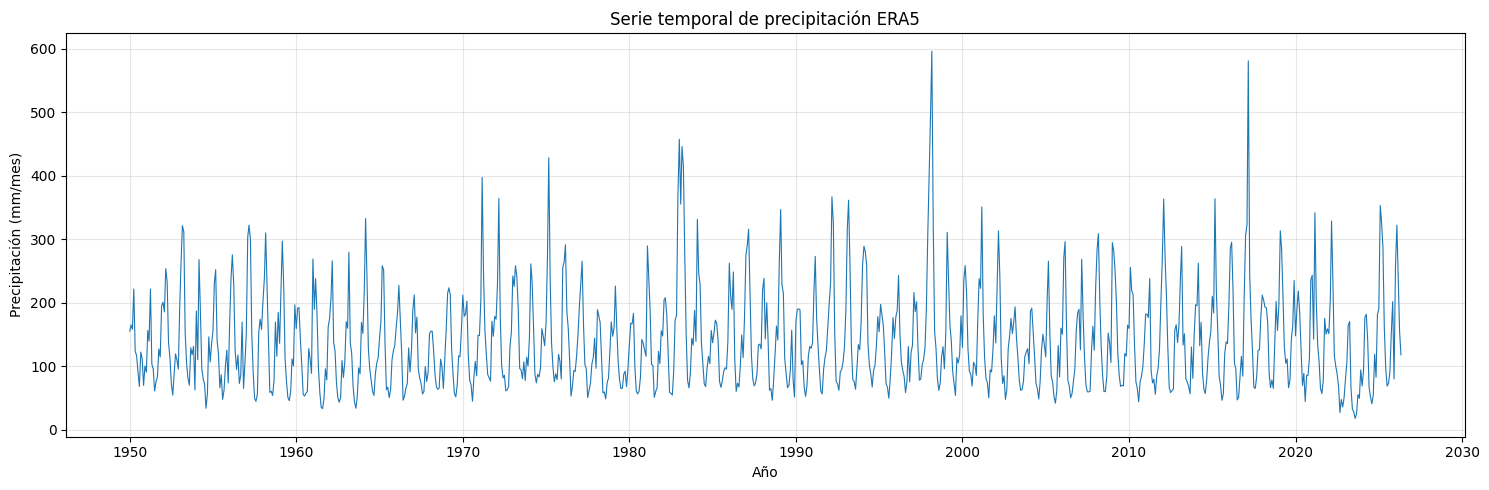

In [12]:
#Serie temporal de precipitación

plt.figure(figsize=(15,5))

plt.plot(
    dataset["fecha"],
    dataset["precipitacion_mm"],
    linewidth=0.8
)

plt.xlabel("Año")
plt.ylabel("Precipitación (mm/mes)")
plt.title("Serie temporal de precipitación ERA5")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

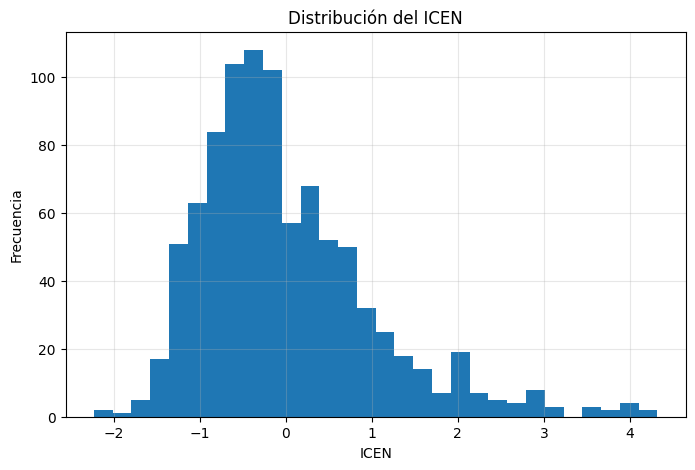

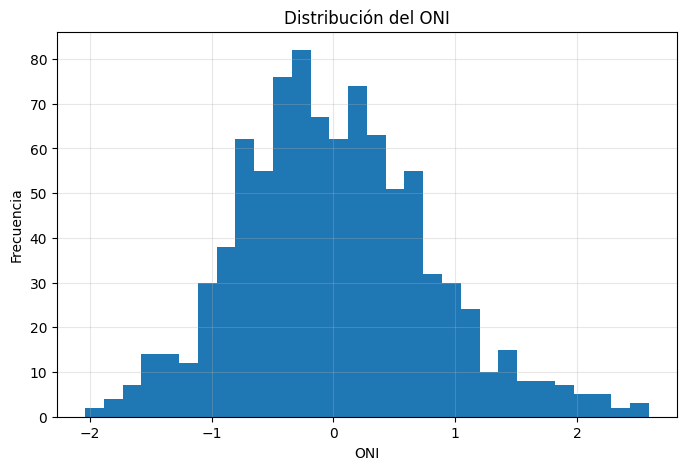

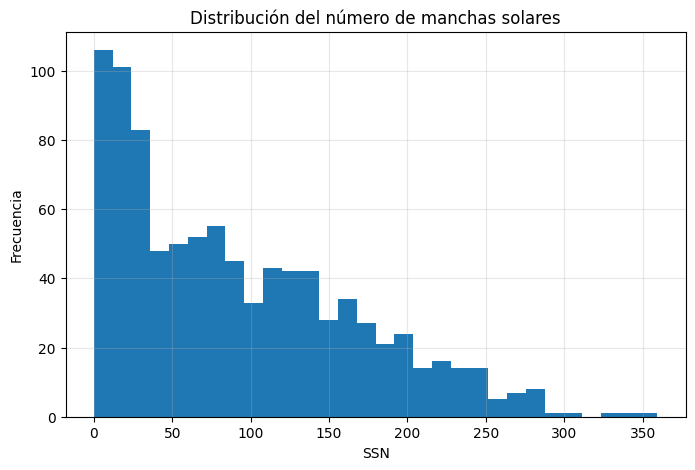

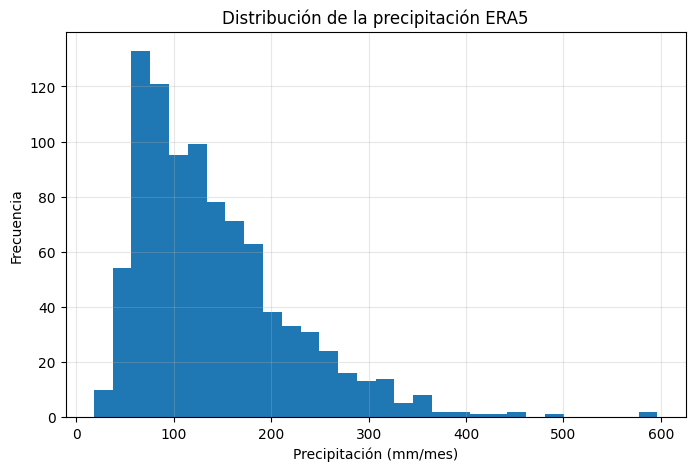

In [18]:
#histograma
plt.figure(figsize=(8,5))
plt.hist(dataset["ICEN"], bins=30)

plt.xlabel("ICEN")
plt.ylabel("Frecuencia")
plt.title("Distribución del ICEN")
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,5))
plt.hist(dataset["ONI"], bins=30)

plt.xlabel("ONI")
plt.ylabel("Frecuencia")
plt.title("Distribución del ONI")
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,5))
plt.hist(dataset["SSN"], bins=30)

plt.xlabel("SSN")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de manchas solares")
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,5))
plt.hist(dataset["precipitacion_mm"], bins=30)

plt.xlabel("Precipitación (mm/mes)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la precipitación ERA5")
plt.grid(alpha=0.3)

plt.show()

In [19]:
#Asimetría de las variables
print("Asimetría de las variables:\n")

for variable in variables:
    print(
        variable,
        ":",
        round(dataset[variable].skew(), 3)
    )

Asimetría de las variables:

ICEN : 1.255
ONI : 0.371
SSN : 0.776
precipitacion_mm : 1.409


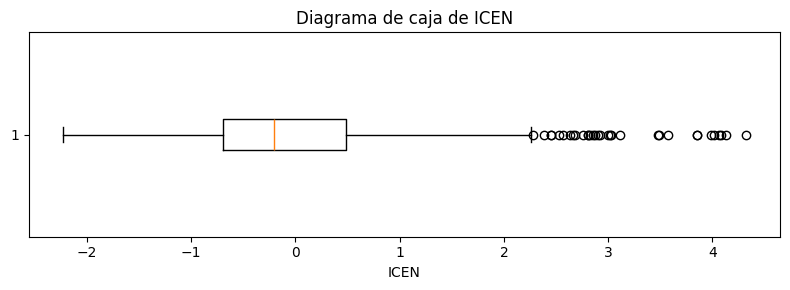

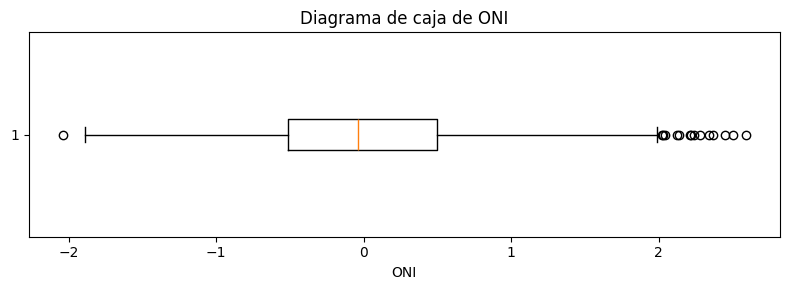

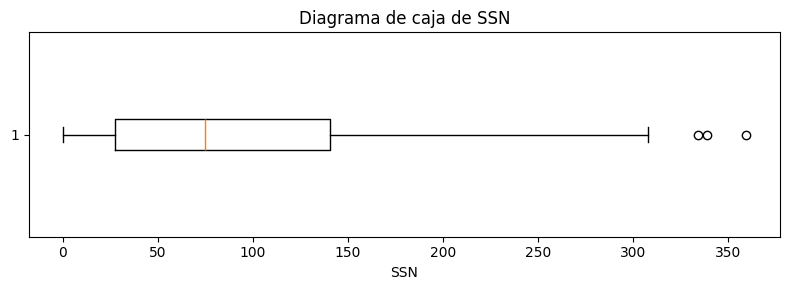

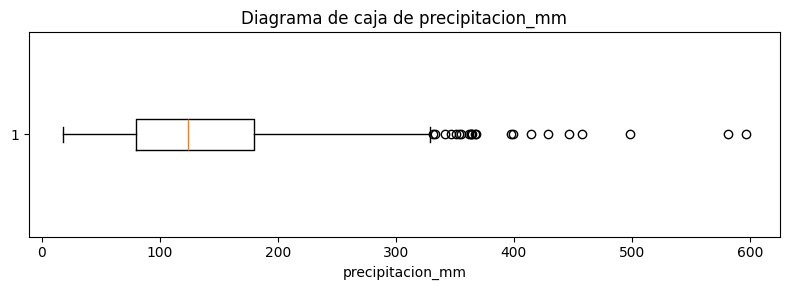

In [22]:
#Boxplots para detectar posibles valores extremos

for variable in variables:

    plt.figure(figsize=(8,3))

    plt.boxplot(
        dataset[variable].dropna(),
        vert=False
    )

    plt.xlabel(variable)
    plt.title(
        f"Diagrama de caja de {variable}"
    )

    plt.tight_layout()
    plt.show()

